# Study 325 -- Crypto-Fear-Greed -- a quantitative teardown 🔬
### Real BTC tape · price-derived gauge · HAC inference · block bootstrap · shuffled-gauge null · capacity

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Gauge: Price--derived_proxy](https://img.shields.io/badge/Gauge-Price--derived_proxy-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) --
*same beats, every claim now carrying its standard error.*

> ⚠️ **Not investment advice.** Real tape: BTC-USD daily (yfinance, auto-adjusted),
> 2014--2026, cache-first. Methods: HAC (Newey-West) *t*, circular block bootstrap,
> shuffled-gauge null. Literature in [`docs/references.md`](../docs/references.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.
> House style in [METHODOLOGY.md](../../../METHODOLOGY.md).


## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from crypto_fear_greed import data, strategy as st
import pandas as pd

# Real tape: cache-first, drop the partial current month so the as-of is clean.
AS_OF = pd.Timestamp("2026-05-31")
_close = data.load_real(fetch=False)
if _close is not None:
    _close = _close[_close.index <= AS_OF]
    panel = data.panel_from_close(_close)
    fr = st.forward_returns(panel)
    spread = st.spread_returns(fr)
    rm = st.regime_means(fr)
    HAVE_REAL = True
    print(f"REAL BTC tape: {_close.index[0].date()} -> {_close.index[-1].date()} ({len(_close)} days)")
else:
    panel = fr = spread = rm = None
    HAVE_REAL = False
    print("No BTC cache -- frozen headline numbers (R dict, mirror of docs/results.md) will be used.")


REAL BTC tape: 2014-09-17 -> 2026-05-31 (4275 days)


In [2]:

# Frozen real-tape headline numbers (mirror of docs/results.md, as-of 2026-05-31).
R = {'n_days': 4275, 'gauge_rows': 4125, 'stamp': '2014-09-17 -> 2026-05-31', 'fingerprint': '26bfad39f376', 'uncond_ann': 71.91, 'ef_ann': 125.49, 'ef_t': 2.12, 'ef_n': 603, 'fear_ann': 35.18, 'fear_t': 0.77, 'fear_n': 850, 'neu_ann': -3.01, 'neu_t': -0.07, 'neu_n': 619, 'greed_ann': 53.64, 'greed_t': 1.66, 'greed_n': 1363, 'eg_ann': 173.76, 'eg_t': 3.58, 'eg_n': 689, 'spread_bps': -2.93, 'spread_ann': -10.68, 'spread_t': -0.86, 'spread_hit': 0.153, 'spread_sr': -0.26, 'spread_ci_lo': -0.869, 'spread_ci_hi': 0.357, 'spread_frac_neg': 79, 'fear_excess_ann': 53.58, 'fear_excess_t': 0.9, 'slope_bps': 9.44, 'slope_t': 0.73, 'sub_a_ann': -11.74, 'sub_a_t': -0.46, 'sub_a_n': 1461, 'sub_b_ann': 10.94, 'sub_b_t': 0.51, 'sub_b_n': 1096, 'sub_c_ann': -23.94, 'sub_c_t': -1.5, 'sub_c_n': 1246, 'null_mean_bps': -0.31, 'null_std_bps': 2.93, 'real_pctile': 17.9, 'pct_long': 14.6, 'pct_flat': 68.7, 'pct_short': 16.7, 'n_trades': 362, 'trades_per_year': 32.0, 'net_ann': -15.56, 'net_t': -1.25, 'ctrl_0_bps': -3.39, 'ctrl_0_t': -0.83, 'ctrl_20_bps': 4.14, 'ctrl_20_t': 1.11, 'ctrl_35_bps': 10.99, 'ctrl_35_t': 2.88, 'ctrl_50_bps': 22.31, 'ctrl_50_t': 5.37}


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| Signal | **None** | Contrarian spread HAC *t* = -0.86 (wrong sign); bootstrap Sharpe CI 79% negative; 17.9th-percentile vs shuffled-gauge null; strongest band is Extreme Greed (*t* = +3.58). |
| Tradability | **Mirage** | Loses gross; crypto short funding (1000 bps/yr) deepens it to -15.6%/yr. |
| Gauge construction | **Price-derived proxy** | vol + drawdown + momentum, not the social/search index (which is network-blocked). |

> 💡 **In plain words:** the contrarian trade doesn't just fail to work -- it works
> in *reverse*, because BTC trends. The synthetic control below proves the engine
> isn't broken: it finds the effect the instant we plant real mean reversion.


## 1 · The claim, steelmanned

- **H₁** -- forward BTC returns are *higher* after Extreme Fear than after Extreme
  Greed (monotone-decreasing band means).
- **H₂** -- the contrarian fear-minus-greed spread has a positive mean with HAC
  *t* >= 2.
- **H₃** -- the linear slope of forward return on the gauge is *negative* (more
  greed -> lower next-day return).


## 3 · How we'd know -- the protocol & the positive control

Before trusting a null we confirm the machinery *can* see a contrarian effect.
`data.synthetic_btc(reversion=...)` plants short-horizon mean reversion (the only
thing a fear-buying rule can harvest); `reversion=0` is a pure random walk.

> 💡 **In plain words:** the smoke test. If the synthetic control stayed dark, a
> flat real result would just mean the code was broken.


In [3]:
print("SYNTHETIC positive control -- reversion knob (n=2500 days, seed=325):")
for rev in [0.0, 0.2, 0.35, 0.5]:
    d, _ = data.synthetic_btc(reversion=rev, seed=325)
    f = st.forward_returns(data.panel_from_close(d["close"]))
    sc = st.summarize(st.spread_returns(f))
    flag = "  <- clears t>2" if sc["tstat"] > 2 else ""
    print(f"  reversion={rev:.2f} -> spread {sc['mean']*1e4:+7.2f} bps/d  HAC t={sc['tstat']:+.2f}{flag}")
print("\nFrozen: rev=0 t=%.2f (null band), rev=0.50 t=%.2f (clears the bar). The engine works." % (R['ctrl_0_t'], R['ctrl_50_t']))


SYNTHETIC positive control -- reversion knob (n=2500 days, seed=325):


  reversion=0.00 -> spread   -3.39 bps/d  HAC t=-0.83


  reversion=0.20 -> spread   +4.14 bps/d  HAC t=+1.11


  reversion=0.35 -> spread  +10.99 bps/d  HAC t=+2.88  <- clears t>2


  reversion=0.50 -> spread  +22.31 bps/d  HAC t=+5.37  <- clears t>2

Frozen: rev=0 t=-0.83 (null band), rev=0.50 t=5.37 (clears the bar). The engine works.


## 4 · The teardown -- band conditional means with HAC *t*-stats

In [4]:
bands = ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]
if HAVE_REAL:
    print(f"=== Forward daily return by band (REAL BTC) ===  Unconditional: {fr['fwd_ret'].mean()*365*100:+.2f}%/yr\n")
    for b in bands:
        row = rm.loc[b]
        print(f"  {b:14s} n={int(row['n']):5d}  {row['mean_ann']*100:+9.2f}%/yr  HAC t={row['tstat']:+5.2f}  hit={row['hit']:.3f}")
else:
    print("Frozen band table (mirror of docs/results.md):")
    for b,a,t,n in [("Extreme Fear",R['ef_ann'],R['ef_t'],R['ef_n']),("Fear",R['fear_ann'],R['fear_t'],R['fear_n']),
                    ("Neutral",R['neu_ann'],R['neu_t'],R['neu_n']),("Greed",R['greed_ann'],R['greed_t'],R['greed_n']),
                    ("Extreme Greed",R['eg_ann'],R['eg_t'],R['eg_n'])]:
        print(f"  {b:14s} n={n:5d}  {a:+9.2f}%/yr  HAC t={t:+5.2f}")
print("\nH1 needs Extreme Fear >> Extreme Greed. We observe the OPPOSITE: Extreme Greed is the top band.")


=== Forward daily return by band (REAL BTC) ===  Unconditional: +71.91%/yr

  Extreme Fear   n=  603    +125.49%/yr  HAC t=+2.12  hit=0.531
  Fear           n=  850     +35.18%/yr  HAC t=+0.77  hit=0.515
  Neutral        n=  619      -3.01%/yr  HAC t=-0.07  hit=0.507
  Greed          n= 1363     +53.64%/yr  HAC t=+1.66  hit=0.528
  Extreme Greed  n=  689    +173.76%/yr  HAC t=+3.58  hit=0.550

H1 needs Extreme Fear >> Extreme Greed. We observe the OPPOSITE: Extreme Greed is the top band.


## The decisive series: the contrarian fear-minus-greed spread

In [5]:
if HAVE_REAL:
    s_sp = st.summarize(spread); s_a = st.annualise(s_sp)
    fe = st.long_only_fear_excess(fr); s_fe = st.summarize(fe)
    sl = st.sentiment_slope(fr)
    ci = st.block_bootstrap_sharpe_ci(spread, n_boot=2000, seed=325)
    print("=== Primary spec: long Extreme Fear, short Extreme Greed, 1-day hold ===")
    print(f"Spread: {s_sp['mean']*1e4:+.2f} bps/d = {s_sp['mean']*365*100:+.2f}%/yr  HAC t={s_sp['tstat']:+.2f}  hit={s_sp['hit_rate']:.3f}  SR(ann)={s_a.get('sharpe_ann', float('nan')):+.2f}")
    print(f"Block-bootstrap Sharpe 95% CI: [{ci['ci_low']:+.3f}, {ci['ci_high']:+.3f}]  ({ci['frac_negative']*100:.0f}% negative)")
    print(f"Long-only fear excess: {s_fe['mean']*365*100:+.2f}%/yr  HAC t={s_fe['tstat']:+.2f}  n={s_fe['n']}")
    print(f"Linear gauge slope: {sl['slope']*1e4:+.2f} bps per 50 pts  HAC t={sl['tstat']:+.2f}  (WRONG sign for contrarian)")
else:
    print(f"Frozen spread: {R['spread_ann']:+.2f}%/yr  HAC t={R['spread_t']:+.2f}  hit={R['spread_hit']:.3f}")
    print(f"Bootstrap Sharpe CI: [{R['spread_ci_lo']:+.3f}, {R['spread_ci_hi']:+.3f}]  ({R['spread_frac_neg']}% negative)")
    print(f"Long-only fear excess: {R['fear_excess_ann']:+.2f}%/yr  HAC t={R['fear_excess_t']:+.2f}")
    print(f"Linear gauge slope: {R['slope_bps']:+.2f} bps/50pts  HAC t={R['slope_t']:+.2f}  (WRONG sign)")
print("\n> The spread t is negative and far from +2. H2 and H3 both fail.")


=== Primary spec: long Extreme Fear, short Extreme Greed, 1-day hold ===
Spread: -2.93 bps/d = -10.68%/yr  HAC t=-0.86  hit=0.153  SR(ann)=-0.26
Block-bootstrap Sharpe 95% CI: [-0.869, +0.357]  (79% negative)
Long-only fear excess: +53.58%/yr  HAC t=+0.90  n=603
Linear gauge slope: +9.44 bps per 50 pts  HAC t=+0.73  (WRONG sign for contrarian)

> The spread t is negative and far from +2. H2 and H3 both fail.


## Shuffled-gauge null: real signal vs random relabelling

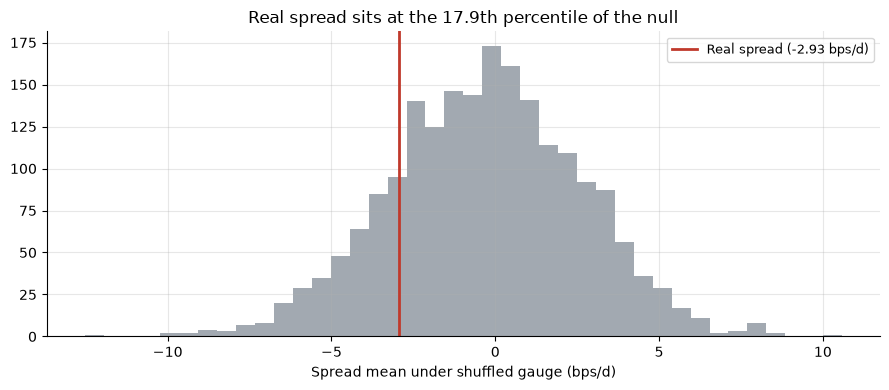

Real spread at the 17.9th percentile -- a random relabelling of the gauge does BETTER on average.


In [6]:
if HAVE_REAL:
    null = st.random_timing_null(fr, n_draws=2000, seed=325)
    real_mean = spread.mean(); pctile = (null < real_mean).mean()*100
else:
    null = None; real_mean = R["spread_bps"]/1e4; pctile = R["real_pctile"]
fig, ax = plt.subplots(figsize=(9, 4))
if null is not None:
    ax.hist(null.values*1e4, bins=40, color=GREY, alpha=0.8)
else:
    import numpy as _np
    ax.hist(_np.random.default_rng(0).normal(R["null_mean_bps"], R["null_std_bps"], 2000), bins=40, color=GREY, alpha=0.8)
ax.axvline(real_mean*1e4, color=RED, lw=2.0, label=f"Real spread ({real_mean*1e4:+.2f} bps/d)")
ax.set_xlabel("Spread mean under shuffled gauge (bps/d)")
ax.set_title(f"Real spread sits at the {pctile:.1f}th percentile of the null")
ax.legend(fontsize=9); plt.tight_layout()
plt.savefig("../docs/null_hist.png", dpi=120, bbox_inches="tight"); plt.show()
print(f"Real spread at the {pctile:.1f}th percentile -- a random relabelling of the gauge does BETTER on average.")


## Sub-period decay -- no era rescues it

  2016-2019: -11.74%/yr  HAC t=-0.46  n=1461
  2020-2022: +10.94%/yr  HAC t=+0.51  n=1096
  2023-2026: -23.94%/yr  HAC t=-1.50  n=1246


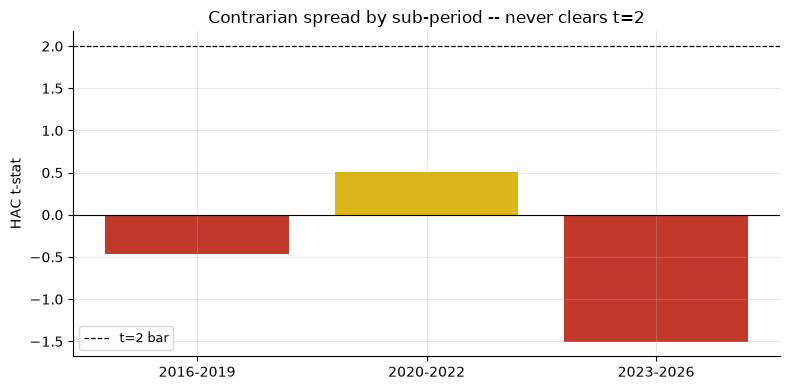

In [7]:
periods = [("2016-2019","2016","2019"),("2020-2022","2020","2022"),("2023-2026","2023","2026")]
if HAVE_REAL:
    rows = []
    for label,a,b in periods:
        s = st.summarize(spread[a:b]); rows.append({"period":label,"ann":s["mean"]*365*100,"t":s["tstat"],"n":s["n"]})
        print(f"  {label}: {s['mean']*365*100:+.2f}%/yr  HAC t={s['tstat']:+.2f}  n={s['n']}")
    sts = pd.DataFrame(rows)
else:
    sts = pd.DataFrame([
        {"period":"2016-2019","ann":R["sub_a_ann"],"t":R["sub_a_t"],"n":R["sub_a_n"]},
        {"period":"2020-2022","ann":R["sub_b_ann"],"t":R["sub_b_t"],"n":R["sub_b_n"]},
        {"period":"2023-2026","ann":R["sub_c_ann"],"t":R["sub_c_t"],"n":R["sub_c_n"]}])
    for _,r in sts.iterrows():
        print(f"  {r['period']}: {r['ann']:+.2f}%/yr  HAC t={r['t']:+.2f}  n={int(r['n'])}")
fig, ax = plt.subplots(figsize=(8, 4))
colors_sub = [GREEN if t>=2 else RED if t<0 else AMBER for t in sts["t"]]
ax.bar(sts["period"], sts["t"], color=colors_sub)
ax.axhline(2.0, color="black", ls="--", lw=0.9, label="t=2 bar"); ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("HAC t-stat"); ax.set_title("Contrarian spread by sub-period -- never clears t=2")
ax.legend(fontsize=9); plt.tight_layout(); plt.show()


## 6 · Could you trade it? -- turnover and crypto-realistic funding

In [8]:
if HAVE_REAL:
    ts = st.turnover_stats(fr)
    net = st.net_spread_returns(fr, one_way_bps=10.0, borrow_bps_ann=1000.0); s_net = st.summarize(net)
    print(f"States: long {ts['pct_long']:.1%}, flat {ts['pct_flat']:.1%}, short {ts['pct_short']:.1%}")
    print(f"Trades: {ts['n_trades']} ({ts['trades_per_year']:.1f}/yr)")
    print(f"Net spread @10bps one-way + 1000bps/yr funding: {s_net['mean']*365*100:+.2f}%/yr  HAC t={s_net['tstat']:+.2f}")
else:
    print(f"States: long {R['pct_long']:.1f}%, flat {R['pct_flat']:.1f}%, short {R['pct_short']:.1f}%")
    print(f"Trades: {R['n_trades']} ({R['trades_per_year']:.1f}/yr)")
    print(f"Net spread @10bps + 1000bps/yr funding: {R['net_ann']:+.2f}%/yr  HAC t={R['net_t']:+.2f}")
print("\n> No gross edge to erode -- it loses before costs, and short funding only deepens the loss.")


States: long 14.6%, flat 68.7%, short 16.7%
Trades: 362 (32.0/yr)
Net spread @10bps one-way + 1000bps/yr funding: -15.56%/yr  HAC t=-1.25

> No gross edge to erode -- it loses before costs, and short funding only deepens the loss.


## 5/7 · The verdict & what to fork

In [9]:
print("=== Study 325 -- Crypto-Fear-Greed ===\n")
print("Signal: NONE")
print(f"  Contrarian spread HAC t = {R['spread_t']:+.2f}  (wrong sign; bar is t>=2)")
print(f"  Bootstrap Sharpe CI [{R['spread_ci_lo']:+.2f}, {R['spread_ci_hi']:+.2f}], {R['spread_frac_neg']}% negative")
print(f"  Real spread at {R['real_pctile']:.1f}th percentile of shuffled-gauge null")
print(f"  Strongest band is Extreme GREED (t={R['eg_t']:+.2f}) -- a crypto-momentum artefact\n")
print("Tradability: MIRAGE -- loses gross; 1000 bps/yr short funding -> %.1f%%/yr net\n" % R['net_ann'])
print("Gauge: PRICE-DERIVED PROXY (vol+drawdown+momentum), not the social/search index.")
print("\nFork: the index as a momentum CONFIRM, the live API, ETH/alt basket. (docs/results.md)")


=== Study 325 -- Crypto-Fear-Greed ===

Signal: NONE
  Contrarian spread HAC t = -0.86  (wrong sign; bar is t>=2)
  Bootstrap Sharpe CI [-0.87, +0.36], 79% negative
  Real spread at 17.9th percentile of shuffled-gauge null
  Strongest band is Extreme GREED (t=+3.58) -- a crypto-momentum artefact

Tradability: MIRAGE -- loses gross; 1000 bps/yr short funding -> -15.6%/yr net

Gauge: PRICE-DERIVED PROXY (vol+drawdown+momentum), not the social/search index.

Fork: the index as a momentum CONFIRM, the live API, ETH/alt basket. (docs/results.md)
